In [1]:
import google.auth
import numpy as np
import pandas as pd
import geopandas as gpd
from calitp_data_analysis import geography_utils
from calitp_data_analysis.sql import to_snakecase
from shared_utils import arcgis_query

In [2]:

import re
import pyarrow.parquet as pq
import gcsfs

In [3]:

import gc
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union


In [4]:
from calitp_data_analysis import get_fs
fs = get_fs()

In [5]:

import os
from typing import List, Optional, Union
import pyarrow.dataset as ds
from google.cloud import storage

In [6]:
import google.auth
import pandas_gbq

credentials, project = google.auth.default()
from functools import cache

from calitp_data_analysis.gcs_pandas import GCSPandas
from calitp_data_analysis.gcs_geopandas import GCSGeoPandas
from calitp_data_analysis.sql import to_snakecase

In [7]:
from typing import List

In [8]:
import geopandas as gpd
import pandas as pd

In [9]:
from functools import cache

from calitp_data_analysis.gcs_geopandas import GCSGeoPandas

@cache
def gcs_geopandas():
    return GCSGeoPandas()

In [10]:
@cache
def gcs_pandas():
    return GCSPandas()

In [11]:
gcsgp = GCSGeoPandas()

In [12]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Census Blocks

In [13]:
census_block_url = "gs://calitp-analytics-data/data-analyses/equity_index/unbuffered_censusblocks_2020/combined_unbufferd_ca_2020.parquet"

In [14]:
census_df = to_snakecase(gcsgp.read_parquet(
   census_block_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [15]:
census_df.sample()

,statefp20,countyfp20,tractce20,blockce20,geoid20,name20,mtfcc20,ur20,uace20,uatype20,funcstat20,aland20,awater20,intptlat20,intptlon20,housing20,pop20,geometry,county_name
126570,06,037,107020,4004,060371070204004,Block 4004,G5040,U,51445,U,S,9987,0,+34.2944500,-118.4501583,24,100,"POLYGON ((142566.890 -412344.968, 142640.582 -412263.531, 142644.764 -412260.355, 142650.347 -412258.377, 142664.332 -412257.927, 142664.633 -412276.343, 142665.592 -412284.317, 142675.133 -412321.781, 142678.277 -412328.277, 142682.984 -412334.636, 142705.213 -412354.248, 142707.088 -412356.325, 142712.546 -412369.220, 142685.752 -412380.090, 142648.439 -412395.015, 142643.469 -412395.096, 142639.577 -412393.495, 142621.928 -412378.137, 142611.026 -412370.103, 142603.212 -412365.126, 142588.821 -412357.593, 142574.361 -412351.504, 142566.890 -412344.968))",Los Angeles


In [16]:
original_eqi_url = "gs://calitp-analytics-data/data-analyses/equity_index/original_work/origial_eqi_index.xls"

In [17]:
eqi_df = gcs_pandas().read_excel(original_eqi_url)

In [18]:
census_df.shape

(519723, 19)

In [19]:
test_blocks = ['060750204024001', '060750260031011', '060750230032004']

In [20]:
census_df.columns

Index(['statefp20', 'countyfp20', 'tractce20', 'blockce20', 'geoid20',
       'name20', 'mtfcc20', 'ur20', 'uace20', 'uatype20', 'funcstat20',
       'aland20', 'awater20', 'intptlat20', 'intptlon20', 'housing20', 'pop20',
       'geometry', 'county_name'],
      dtype='object')

In [21]:
sf_only = census_df.loc[census_df.countyfp20 == "085"]

In [22]:
sf_only.shape

(18178, 19)

In [139]:
sf_only.county_name.unique()

array(['Santa Clara'], dtype=object)

In [23]:
sf_only.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 18178 entries, 426676 to 444853
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   statefp20    18178 non-null  object  
 1   countyfp20   18178 non-null  object  
 2   tractce20    18178 non-null  object  
 3   blockce20    18178 non-null  object  
 4   geoid20      18178 non-null  object  
 5   name20       18178 non-null  object  
 6   mtfcc20      18178 non-null  object  
 7   ur20         18178 non-null  object  
 8   uace20       16914 non-null  object  
 9   uatype20     16914 non-null  object  
 10  funcstat20   18178 non-null  object  
 11  aland20      18178 non-null  int64   
 12  awater20     18178 non-null  int64   
 13  intptlat20   18178 non-null  object  
 14  intptlon20   18178 non-null  object  
 15  housing20    18178 non-null  int64   
 16  pop20        18178 non-null  int64   
 17  geometry     18178 non-null  geometry
 18  county_name  1817

## HPMS

In [24]:


hpms_url = "gs://calitp-analytics-data/data-analyses/equity_index/HPMS21_Main_SUCU.parquet"



In [25]:
 hpm_df = to_snakecase(gcsgp.read_parquet(
   hpms_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [26]:
# Filter to f_system 1,2 temporarily
# hpm_df2 = hpm_df.loc[hpm_df.f_system.isin([1,2])]

In [27]:
buffer_list = [500, 450, 400, 350, 300, 250, 200, 150, 100, 50]

In [28]:
# hpm_df.geometry = hpm_df.geometry.buffer(50)

In [29]:
#hpm_df.to_parquet("./buffered.parquet")
#fs.put("./buffered.parquet", f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_50_hpm.parquet")

In [30]:
#for buffer in [150,100]:
  # df = buffer_hpm(gdf=hpm_df, buffer = buffer)

In [31]:
"""

dims = set(
    len(pt)
    for geom in hpm_df.geometry
    for line in geom.geoms            # iterate through each LineString
    for pt in line.coords             # now safe to access coords
)

"""

'\n\ndims = set(\n    len(pt)\n    for geom in hpm_df.geometry\n    for line in geom.geoms            # iterate through each LineString\n    for pt in line.coords             # now safe to access coords\n)\n\n'

In [32]:
# hpm_gdf = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_500_hpm.parquet")

In [33]:
# intersect = gpd.overlay(hpm_gdf, sf_only, how = "intersection",keep_geom_type= False)

## Main function

In [34]:
def intersect_hpm_census(hpm_gdf: gpd.GeoDataFrame, census_gdf:gpd.GeoDataFrame, buffer: int, file_name:str)->pd.DataFrame:
    hpm_gdf.geometry = hpm_gdf.geometry.buffer(buffer)

    intersect = gpd.overlay(hpm_gdf, census_gdf, how = "intersection",keep_geom_type= False)

    # Create an unique ID 
    intersect["unique_id"] = intersect.routeid + "_" + intersect.geoid20

    # Combine the geometries for each unique_id and find the max AADT
    dissolved = intersect.dissolve(
    by=["geoid20", "unique_id",],
    aggfunc={
        "aadt": "max",     # Get the max for each unique_id
    }).reset_index()

    # Find the area for each unique_id
    dissolved["area"] = dissolved.geometry.area

    # Need to find the sum of the area for a censusblock
    agg = dissolved.groupby("geoid20").agg({"aadt":"sum", "area":"sum"}).reset_index()

    # Calculate the score
    agg[f"aadt_{buffer}_score"] = agg.aadt * agg.area

    agg = agg[["geoid20",f"aadt_{buffer}_score"]]
    # Save to GCS
    agg.to_parquet("./agg2.parquet")
    fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/{file_name}_traffic_proximity_overlay_{buffer}.parquet")
    print(f"finshed saving data for {buffer}")
    
    return agg

In [35]:

def intersect_hpm_census_streaming(
    hpm_gdf: gpd.GeoDataFrame,
    census_gdf: gpd.GeoDataFrame,
    buffer_m: int,
    out_path: str,
    batch_size: int = 10000,
    target_crs: str = "EPSG:3310",  # CA Albers; change if your project uses another CRS
    simplify_tolerance: float | None = None,  # e.g., 0.5–2.0 meters if you want vertex reduction
) -> pd.DataFrame:
    """
    Memory-safe EQI traffic overlay:
    - project to area-safe CRS
    - buffer with lower resolution
    - prefilter with sjoin
    - clip only candidates
    - union geometry per unique_id + max AADT
    - compute area & weighted score
    - aggregate by geoid20
    - stream in batches and write partials
    """

    # 0) Project to target CRS (area-safe)
    hpm_gdf = hpm_gdf.to_crs(target_crs)[["routeid", "aadt", "geometry"]].copy()
    census_gdf = census_gdf.to_crs(target_crs)[["geoid20", "geometry"]].copy()

    # 1) Buffer the HPMS lines with *lower resolution*; optional simplify
    #    Resolution reduces circular arc vertices (default 16). Try 8 or even 4.
    hpm_gdf["geometry"] = hpm_gdf.geometry.buffer(buffer_m, resolution=8)
    if simplify_tolerance is not None:
        # Drop high-frequency vertices produced by buffer; preserves topology
        hpm_gdf["geometry"] = hpm_gdf.geometry.simplify(simplify_tolerance, preserve_topology=True)

    # Pre-allocate partial outputs
    partial_scores = []

    # 2) Stream in batches to bound peak memory
    for i in range(0, len(hpm_gdf), batch_size):
        batch = hpm_gdf.iloc[i:i+batch_size].copy()

        # 3) Candidate pairs via spatial join (fast, keeps original left geom)
        #    predicate="intersects" avoids computing expensive overlay for non-candidates
        cand = gpd.sjoin(batch, census_gdf, predicate="intersects", how="inner")

        if cand.empty:
            del batch, cand
            gc.collect()
            continue

        # 4) Compute exact intersection geometry only for candidates
        #    We clip the buffered road to the block it overlaps
        #    Using index_right created by sjoin to fetch the block geometry quickly
        block_geom = census_gdf.loc[cand.index_right, "geometry"].values
        cand["geometry"] = [
            geom.intersection(block_geom[idx])
            for idx, geom in enumerate(cand.geometry.values)
        ]
        cand = cand.drop(columns=["index_right"])  # no longer needed

        # 5) Build unique_id = RouteID + "____" + GEOID (matches R)
        cand["unique_id"] = cand["routeid"].astype(str) + "____" + cand["geoid20"].astype(str)

        # 6) Dissolve by unique_id → union geometry + max(AADT) (matches R fsummarise)
        dissolved = cand.dissolve(by="unique_id", aggfunc={"aadt": "max"}).reset_index()

        # Optional geometry fix if needed:
        dissolved["geometry"] = dissolved.geometry.buffer(0)

        # 7) Area + weighting (use union area, not fragment area)
        dissolved["area"] = dissolved.geometry.area
        dissolved["weighted_aadt"] = dissolved["aadt"] * dissolved["area"]

        # 8) Recover block ID from unique_id and aggregate to block
        dissolved["geoid20"] = dissolved["unique_id"].str.split("____", n=1).str[1]
        part = dissolved.groupby("geoid20", as_index=False)["weighted_aadt"].sum()

        partial_scores.append(part)

        # Free big objects early
        del batch, cand, dissolved, part
        gc.collect()

    # 9) Combine partials → final block score, name column per buffer
    if not partial_scores:
        final = pd.DataFrame(columns=["geoid20", f"aadt_{buffer_m}_score"])
    else:
        final = (
            pd.concat(partial_scores, ignore_index=True)
            .groupby("geoid20", as_index=False)["weighted_aadt"].sum()
            .rename(columns={"weighted_aadt": f"aadt_{buffer_m}_score"})
        )

    # 10) Persist and return
    final.to_parquet("./agg2.parquet")
    fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/{out_path}_traffic_proximity_overlay_{buffer_m}.parquet")
    return final


In [45]:
for size in [50]:
  sf_df = intersect_hpm_census_streaming(hpm_gdf = hpm_df, census_gdf=sf_only, buffer_m = size, out_path = "sf_test_august20", batch_size = 2000 )

In [44]:
sf_df.shape

(17651, 2)

In [38]:
# df.to_parquet("./agg2.parquet")

In [39]:
# fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/august26_traffic_proximity_overlay_500.parquet")

In [47]:

def load_eqi_traffic_parquets(file_name: str):
    """
    Reads all EQI traffic parquet files from the GCS folder
    and concatenates them together row-wise (stacked).
    """
    sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
    dfs = []

    for size in sizes:
        path = f"{file_name}{size}.parquet"
        df = gcs_pandas().read_parquet(path)
        dfs.append(df)

    # Merge all dfs on geoid20
    combined = dfs[0]
    for df in dfs[1:]:
        combined = combined.merge(df, on="geoid20", how="outer")

    if "geoid20" not in combined.columns:
        raise ValueError("Column 'geoid20' not found in concatenated data.")

    return combined


In [100]:
# gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_test_august20_traffic_proximity_overlay_100.parquet
df = load_eqi_traffic_parquets(file_name = "gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_test_august20_traffic_proximity_overlay_")

In [50]:
def calc_scores(df:pd.DataFrame, census_gdf:gpd.GeoDataFrame)->gpd.GeoDataFrame:
    df["p_50_m"]  = df["aadt_50_score"]
    df["p_100_m"] = df["aadt_100_score"] - df["aadt_50_score"]
    df["p_150_m"] = df["aadt_150_score"] - df["aadt_100_score"]
    df["p_200_m"] = df["aadt_200_score"] - df["aadt_150_score"]
    df["p_250_m"] = df["aadt_250_score"] - df["aadt_200_score"]
    df["p_300_m"] = df["aadt_300_score"] - df["aadt_250_score"]
    df["p_350_m"] = df["aadt_350_score"] - df["aadt_250_score"]
    df["p_400_m"] = df["aadt_400_score"] - df["aadt_350_score"]
    df["p_450_m"] = df["aadt_450_score"] - df["aadt_400_score"]
    df["p_500_m"] = df["aadt_500_score"] - df["aadt_450_score"]

    weights = {
	        "p_50_m": 1.0,
	        "p_100_m": 0.5,
	        "p_150_m": 0.33,
	        "p_200_m": 0.25,
	        "p_250_m": 0.20,
	        "p_300_m": 0.16,
	        "p_350_m": 0.14,
	        "p_400_m": 0.125,
	        "p_450_m": 0.111,
	        "p_500_m": 0.10,
    }

    for col, w in weights.items():
        df[f"{col}_w"] = df[col] * w

    weighted_cols = [f"{col}_w" for col in weights.keys()]
    df["weighted_aadt_score"] = df[weighted_cols].sum(axis=1)

    df2 = df[["geoid20", "weighted_aadt_score"]].copy().fillna(0)

    df2["traffic_proximity_and_volume_percentile"] = (
	        df2["weighted_aadt_score"].rank(pct=True)
    )

    m1 = pd.merge(census_gdf[["geoid20","county_name", "geometry"]], df2, on = ["geoid20"], how = "left")
    return m1

In [ ]:
# sum_final = calc_scores(df = summed_df, census_gdf = sf_only)

In [ ]:
# max_final = calc_scores(df = max_df, census_gdf = sf_only)

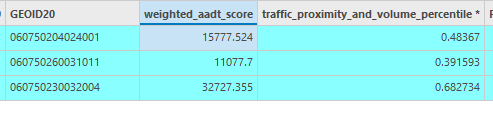

# Compare Scatterplots

In [101]:
df = pd.merge(sf_only[["geoid20","county_name", "geometry"]], df, on = ["geoid20"], how = "left")

In [102]:
df.geoid20 = df.geoid20.astype(str)

In [103]:
df["p_50_m"]  = df["aadt_50_score"]
df["p_100_m"] = df["aadt_100_score"] - df["aadt_50_score"]
df["p_150_m"] = df["aadt_150_score"] - df["aadt_100_score"]
df["p_200_m"] = df["aadt_200_score"] - df["aadt_150_score"]
df["p_250_m"] = df["aadt_250_score"] - df["aadt_200_score"]
df["p_300_m"] = df["aadt_300_score"] - df["aadt_250_score"]
df["p_350_m"] = df["aadt_350_score"] - df["aadt_250_score"]
df["p_400_m"] = df["aadt_400_score"] - df["aadt_350_score"]
df["p_450_m"] = df["aadt_450_score"] - df["aadt_400_score"]
df["p_500_m"] = df["aadt_500_score"] - df["aadt_450_score"]

In [53]:
weights = {
	        "p_50_m": 1.0,
	        "p_100_m": 0.5,
	        "p_150_m": 0.33,
	        "p_200_m": 0.25,
	        "p_250_m": 0.20,
	        "p_300_m": 0.16,
	        "p_350_m": 0.14,
	        "p_400_m": 0.125,
	        "p_450_m": 0.111,
	        "p_500_m": 0.10,
    }

In [104]:
for col, w in weights.items():
    df[f"{col}_w"] = df[col] * w

In [55]:
df.sample()

,geoid20,aadt_50_score,aadt_100_score,aadt_150_score,aadt_200_score,aadt_250_score,aadt_300_score,aadt_350_score,aadt_400_score,aadt_450_score,aadt_500_score,p_50_m,p_100_m,p_150_m,p_200_m,p_250_m,p_300_m,p_350_m,p_400_m,p_450_m,p_500_m,p_50_m_w,p_100_m_w,p_150_m_w,p_200_m_w,p_250_m_w,p_300_m_w,p_350_m_w,p_400_m_w,p_450_m_w,p_500_m_w
15743,060855120391003,512230134.53,3225758500.96,6539092920.66,9436025264.61,13106928359.01,14876475823.05,17629532489.13,21062737790.80,25935327145.96,30077705459.46,512230134.53,2713528366.42,3313334419.70,2896932343.95,3670903094.40,1769547464.05,4522604130.12,3433205301.67,4872589355.16,4142378313.51,512230134.53,1356764183.21,1093400358.50,724233085.99,734180618.88,283127594.25,633164578.22,429150662.71,540857418.42,414237831.35


In [105]:
weighted_cols = [f"{col}_w" for col in weights.keys()]
df["weighted_aadt_score"] = df[weighted_cols].sum(axis=1)

In [57]:
df.sample()

,geoid20,aadt_50_score,aadt_100_score,aadt_150_score,aadt_200_score,aadt_250_score,aadt_300_score,aadt_350_score,aadt_400_score,aadt_450_score,aadt_500_score,p_50_m,p_100_m,p_150_m,p_200_m,p_250_m,p_300_m,p_350_m,p_400_m,p_450_m,p_500_m,p_50_m_w,p_100_m_w,p_150_m_w,p_200_m_w,p_250_m_w,p_300_m_w,p_350_m_w,p_400_m_w,p_450_m_w,p_500_m_w,weighted_aadt_score
2209,060855029101006,147614306.85,285516031.00,355120361.24,1110853466.60,1690857327.29,2601100539.43,3490123157.31,4161331621.63,4846741314.32,5557743805.19,147614306.85,137901724.15,69604330.24,755733105.35,580003860.69,910243212.14,1799265830.02,671208464.32,685409692.68,711002490.88,147614306.85,68950862.08,22969428.98,188933276.34,116000772.14,145638913.94,251897216.20,83901058.04,76080475.89,71100249.09,1173086559.54


In [106]:
df["traffic_proximity_and_volume_percentile"] = (
	        df["weighted_aadt_score"].rank(pct=True)
    )

In [107]:
df2 = df[["geoid20","weighted_aadt_score","traffic_proximity_and_volume_percentile", "geometry"]]

In [60]:
sf_original_url = "gs://calitp-analytics-data/data-analyses/equity_index/original_work/origial_eqi_index.xls"

In [61]:
sf_original_df = to_snakecase(pd.read_excel(sf_original_url))

In [62]:
sf_original_df.sample()

,objectid,countyfp20,geoid20,ur20,housing20,pop20,median_hh_income,rounded_hh_size,local_low_income_threshold,localized_income_screen,state_income_screen,income_screen,crash_score_local,crash_density_local,crash_percentile_local,weighted_aadt_score,traffic_proximity_and_volume_pe,ped_ratio,bike_ratio,transit_ratio_jobs,transit_ratio_pois,screen,tribal_land_indicator,low_income_indicator,demographic_overlay_screen,traffic_exposure_screen,access_to_destinations_screen,tbpp_screen,underserved_community_screen,shape_length,shape_area
1460,1461,85,60855123082018,U,40,133,171618.00,3.00,106000.00,0,0,0,NaN,NaN,NaN,4207.32,0.21,0.40,0.44,0.00,0.00,Non-Screened Blocks,No,No,No,No,No,No,No,0.01,0.00


In [63]:
sf_original_df.countyfp20.nunique()

1

In [ ]:
sf_original_df

In [64]:
sf_original_df.geoid20 = sf_original_df.geoid20.astype(str)

In [65]:
sf_original_df["traffic_proximity_and_volume_percentile"] = (
	        sf_original_df["weighted_aadt_score"].rank(pct=True)
    )

In [78]:
sf_original_df["geoid20"] = sf_original_df["geoid20"].astype(str).str.zfill(15)

In [69]:
df2.sample()

,geoid20,weighted_aadt_score,traffic_proximity_and_volume_percentile
1129,060855020023009,1928831585.26,0.87


In [74]:
len(df2.geoid20.iloc[0])

15

In [75]:
len(sf_original_df.geoid20.iloc[0])

14

In [76]:
sf_original_df.geoid20.iloc[0]

'60855017001008'

In [77]:
df2.geoid20.iloc[0]

'060855001001000'

In [140]:
merged = pd.merge(df2, sf_original_df,
             on = ["geoid20"],
             suffixes = ("_original", "new"),
             how = "inner")

In [112]:
#merged[["geoid20", "traffic_proximity_and_volume_percentilenew", #"weighted_aadt_scorenew", "traffic_proximity_and_volume_percentile_original", #"weighted_aadt_score_original"]].to_csv("./comparison.csv")

In [141]:
merged = merged[["geoid20", "traffic_proximity_and_volume_percentilenew", "weighted_aadt_scorenew", "traffic_proximity_and_volume_percentile_original", "weighted_aadt_score_original", "geometry"]]

In [142]:
merged["pct_change"] = (merged.traffic_proximity_and_volume_percentile_original-merged.traffic_proximity_and_volume_percentilenew)/merged.traffic_proximity_and_volume_percentile_original

In [158]:
merged["pct_change"].describe()

count   17497.00
mean       -0.21
std         1.34
min       -62.89
25%        -0.21
50%         0.06
75%         0.32
max         1.00
Name: pct_change, dtype: float64

In [143]:
merged.drop(columns = ["geometry"]).sample(10)

,geoid20,traffic_proximity_and_volume_percentilenew,weighted_aadt_scorenew,traffic_proximity_and_volume_percentile_original,weighted_aadt_score_original,pct_change
3676,060855019011000,0.83,77768.31,0.14,97024211.88,-4.84
2719,060855093041010,0.93,158962.87,0.94,4073240253.18,0.01
7896,060855017003008,0.67,45262.94,0.42,323774657.86,-0.60
11633,060855106002000,0.66,43753.28,0.54,462159341.39,-0.22
2690,060855021013020,0.91,131312.25,0.95,4279997082.83,0.04
11961,060855120311003,0.29,14575.84,0.54,462757405.41,0.46
1877,060855122001045,NaN,NaN,0.00,0.00,NaN
9936,060855082051002,0.77,61105.59,0.63,619891004.81,-0.23
13311,060855120551010,0.48,26893.12,0.39,295299963.45,-0.24
9868,060855120261008,0.50,28279.00,0.12,82300128.57,-3.08


In [164]:
extreme_changes = merged.loc[(merged["pct_change"] > 0.32) | (merged["pct_change"] < -0.21)]

In [165]:
extreme_changes.shape

(8750, 7)

In [170]:
#extreme_changes.explore("traffic_proximity_and_volume_percentile_original")

In [150]:
merged.loc[merged["pct_change"] < -61]

,geoid20,traffic_proximity_and_volume_percentilenew,weighted_aadt_scorenew,traffic_proximity_and_volume_percentile_original,weighted_aadt_score_original,geometry,pct_change
11941,060855117051033,0.86,90849.00,0.01,1033007.26,"POLYGON ((-193913.981 -65267.631, -193911.785 -65268.237, -193911.612 -65272.244, -193916.078 -65270.362, -193913.981 -65267.631))",-62.89


In [152]:
1_033_007-90_849

942158

In [146]:
merged["pct_change"].describe()

count   17497.00
mean       -0.21
std         1.34
min       -62.89
25%        -0.21
50%         0.06
75%         0.32
max         1.00
Name: pct_change, dtype: float64

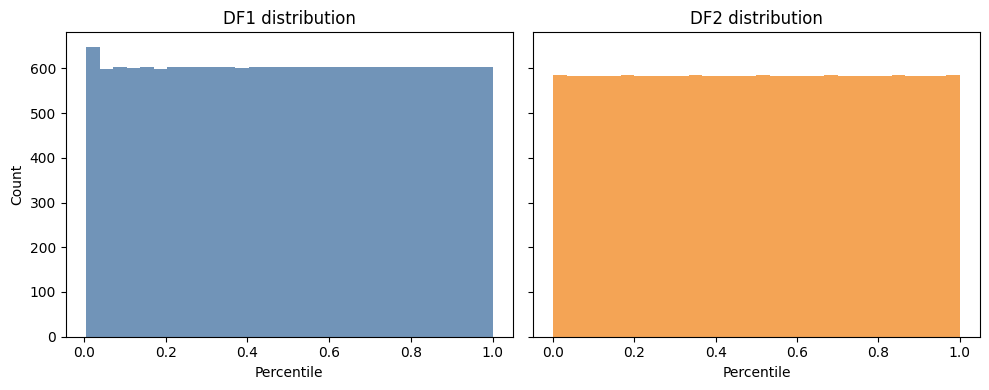

In [124]:

import matplotlib.pyplot as plt

a = merged["traffic_proximity_and_volume_percentile_original"].dropna()
b = merged["traffic_proximity_and_volume_percentilenew"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].hist(a, bins=30, color="#4e79a7", alpha=0.8)
axes[0].set_title("DF1 distribution")
axes[0].set_xlabel("Percentile")
axes[0].set_ylabel("Count")

axes[1].hist(b, bins=30, color="#f28e2b", alpha=0.8)
axes[1].set_title("DF2 distribution")
axes[1].set_xlabel("Percentile")

plt.tight_layout()
plt.show()


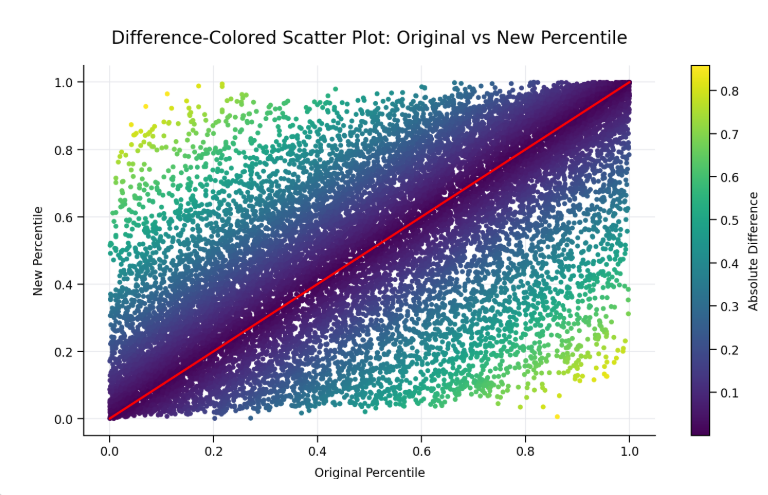